In [1]:
%pip install split-folders
# %pip install seaborn

In [4]:
!unzip -q data/cell_images_1.zip


replace cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [24]:
import os
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import splitfolders
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from PIL import Image
from tensorflow.image import resize
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:

# 1. current working directory
print("Current Directory:", os.getcwd())

# 2. List the files
print("Available Files:", os.listdir('.'))

# 3. Define the paths
parasitized_path = "/content/cell_images/Parasitized"
uninfected_path = "/content/cell_images/Uninfected"

if os.path.exists(parasitized_path):
    print(f"Found {len(os.listdir(parasitized_path))} images in Parasitized folder.")
    print(f"Found {len(os.listdir(uninfected_path))} images in Uninfected folder.")
else:
    print("Error: Path not found!")


Current Directory: /content
Available Files: ['.config', '.ipynb_checkpoints', 'data', 'Untitled Folder', 'cell_images', 'models', 'cell_images_split', 'sample_data']
Found 13779 images in Parasitized folder.
Found 13779 images in Uninfected folder.


## Data Cleaning

### 1. Identify and Remove bad files

In [4]:
# Scan for Bad Images or files

bad_images = []

for folder in [parasitized_path, uninfected_path]:
    for file in os.listdir(folder):
        try:
            Image.open(os.path.join(folder, file))
        except Exception:
            bad_images.append(os.path.join(folder, file))

bad_images

[]

In [5]:
#  Remove bad files that may cause errors in processing

for folder in [parasitized_path, uninfected_path]:
    thumb_path = os.path.join(folder, "Thumbs.db")

    if os.path.exists(thumb_path):
        os.remove(thumb_path)
        print(f"Deleted {thumb_path}")

## Create Training and Validation Sets

TensorFlow has a utility that loads images from folders, splits training/validation data, resizes images, and creates batches.

Why do we need to resize??
CNNs require images of consistent dimensions. Since the malaria images range from roughly 40×46 to nearly 400×385 pixels, we resize them to a fixed size such as 128×128 before training.

In [6]:
import splitfolders

splitfolders.ratio(
    "/content/cell_images",
    output="/content/cell_images_split",
    seed=42,
    ratio=(.8, .1, .1),
    group_prefix=None,
    move=False
)


Copying files: 27558 files [00:07, 3922.44 files/s]


In [8]:
# 1. Load the 80% Training Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/train",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# 2. Load the 10% Validation Data
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/val",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# 3. Load the 10% Testing Data
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/test",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    shuffle = False
)


Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Found 2758 files belonging to 2 classes.


In [9]:
class_names = train_ds.class_names
class_names

['Parasitized', 'Uninfected']

## Visualize Preprocessed Images

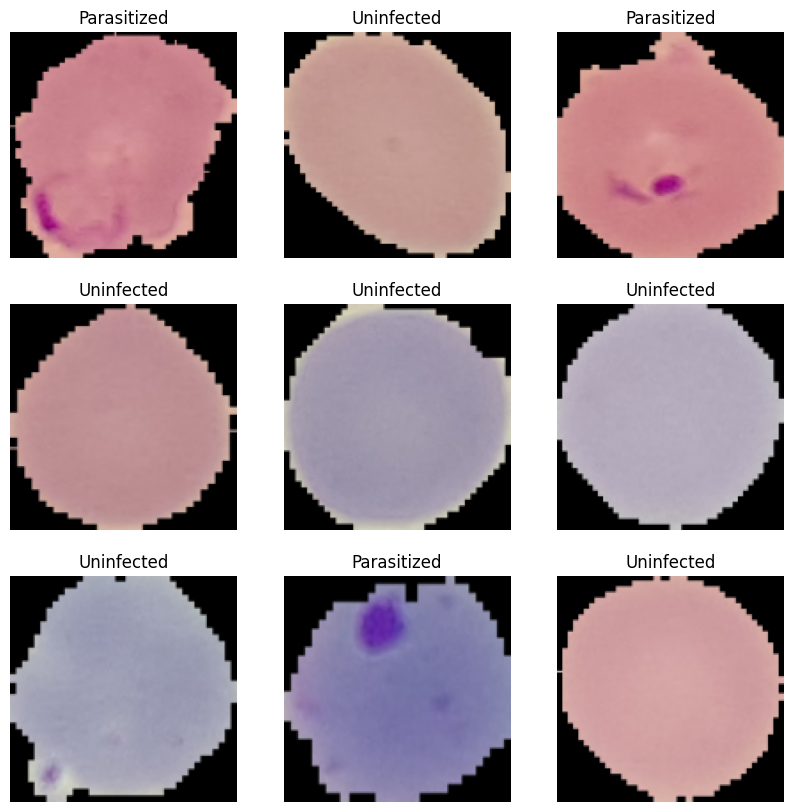

In [10]:

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Normalize Pixel Values (from range 0 - 255 to 0 - 1)
Why??
Pixel values range from 0 to 255. Dividing by 255 scales them to 0–1, which helps gradient-based optimization train more efficiently by preventing the model from giving more priority (weight) to inputs with higher values.

In [39]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [41]:

# 1. Set up the automatic tuning manager
AUTOTUNE = tf.data.AUTOTUNE

# 2. Optimize the Training dataset
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# 3. Optimize the Validation dataset
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 4. Optimize the Testing dataset
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [42]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)
    print(labels[:10].numpy())

(32, 128, 128, 3)
(32,)
[0 1 0 0 1 0 0 0 0 1]


# Model A — CNN from Scratch

Design and train a CNN without any pretrained weights.

## 1. (a) Define the Baseline CNN

In [43]:
model_scratch = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu",
        input_shape=(128, 128, 3)
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=3,
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile the Model

In [44]:
model_scratch.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [35]:
model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,779,905 (14.42 MB)

 Trainable params: 3,779,905 (14.42 MB)

 Non-trainable params: 0 (0.00 B)

## Set EarlyStopping
Set EarlyStopping to automatically stop training when the loss plateaus and begins to fluctuate signifying overfitting

In [46]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

## Train the Model

In [47]:
history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.4985 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.4957 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4950 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.4970 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.4980 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/10
149/689 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.4790 - loss: 0.6933

KeyboardInterrupt: 

In [48]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import gc

# Step 1: Wipe the broken weights and memory from your current session
tf.keras.backend.clear_session()
gc.collect()

# Step 2: Reload the datasets fresh at 128x128
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("Loading datasets from split directories...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Step 3: Clean, Single-Pass Normalization Map (Memory Optimized)
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = layers.Rescaling(1./255)

# Notice: num_parallel_calls protects your RAM, prefetch optimizes your GPU
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Step 4: Rebuild the Model Structure from scratch
model_scratch = models.Sequential([
    layers.Conv2D(32, kernel_size=3, padding="same", activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"), # Added padding safety
    layers.MaxPooling2D(),

    layers.Flatten(), # Your original flatten layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_scratch.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Step 5: Start Clean Training
print("Starting Cleaned Scratch Model Training...")
history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)


Loading datasets from split directories...
Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Starting Cleaned Scratch Model Training...
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.8569 - loss: 0.3407 - val_accuracy: 0.9444 - val_loss: 0.1665
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9550 - loss: 0.1485 - val_accuracy: 0.9528 - val_loss: 0.1505
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.9594 - loss: 0.1285 - val_accuracy: 0.9553 - val_loss: 0.1539
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9631 - loss: 0.1147 - val_accuracy: 0.9488 - val_loss: 0.1533
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9644 - loss: 0.1072 - val_accuracy: 0.9553 - val_loss: 0.1590


## Evaluate on Test Set

In [51]:
# 1. Properly load your test dataset fresh at 128x128
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/test",
    image_size=(128, 128),
    batch_size=32,
    shuffle=False  # Crucial! Keeps the images aligned with their labels for the confusion matrix
)

# 2. Fix the missing normalization mapping step!
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# 3. Evaluate the model (This will now jump up to ~95%)
test_loss, test_accuracy = model_scratch.evaluate(test_ds)
print(f"\nTrue Test Accuracy: {test_accuracy:.4f}")
print(f"True Test Loss: {test_loss:.4f}")

# 4. Generate predictions using the correct, defined variable 'test_ds'
print("\nGenerating model predictions...")
y_pred_probs = model_scratch.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 5. Extract the true target labels out of the dataset to compare
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("Predictions successfully gathered!")


Found 2758 files belonging to 2 classes.
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9550 - loss: 0.1443

True Test Accuracy: 0.9550
True Test Loss: 0.1443

Generating model predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Predictions successfully gathered!


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9550 - loss: 0.1443


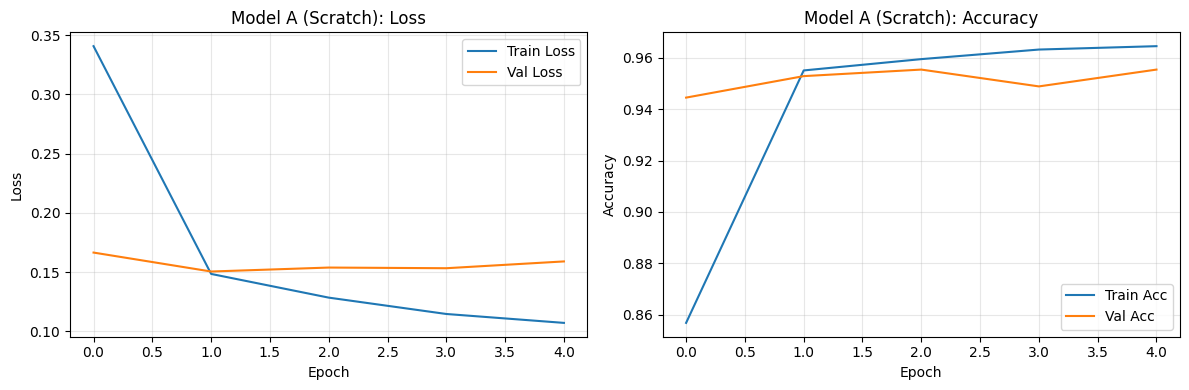

>> What to observe:
Final training accuracy: 0.964
Final validation accuracy: 0.955
Test accuracy: 0.955
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [52]:

# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
# We run model.evaluate on test_ds to get the actual math numbers
test_loss, test_accuracy = model_scratch.evaluate(test_ds)

# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_scratch.history['loss'], label='Train Loss')
axes[0].plot(history_scratch.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model A (Scratch): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_scratch.history['accuracy'], label='Train Acc')
axes[1].plot(history_scratch.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model A (Scratch): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_scratch.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_scratch.history['val_accuracy'][-1]:.3f}")

# Fixed: This line now prints the calculated number instead of the raw pipeline folder
print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized       0.97      0.94      0.95      1379
  Uninfected       0.94      0.97      0.96      1379

    accuracy                           0.96      2758
   macro avg       0.96      0.96      0.96      2758
weighted avg       0.96      0.96      0.96      2758



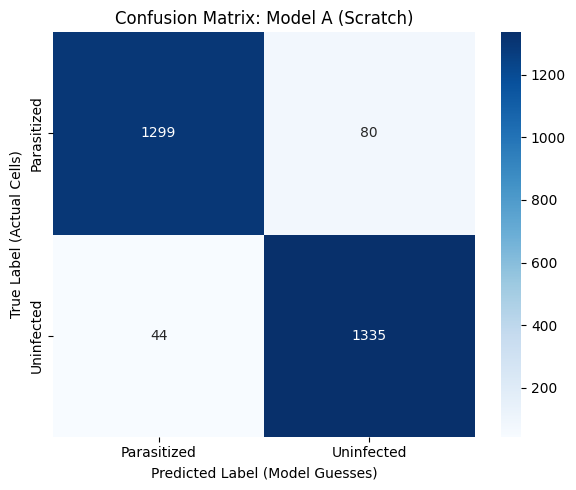

In [53]:

# ==========================================
# STEP 1: GET TRUE LABELS AND PREDICTIONS
# ==========================================

# 1. Extract the true labels from your test dataset pipeline
true_labels = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Get raw probability predictions from the model (numbers between 0 and 1)
raw_predictions = model_scratch.predict(test_ds)

# 3. Convert probabilities to crisp binary choices (0 or 1)
predicted_labels = (raw_predictions > 0.5).astype(int)

# FIX: Manually define the class names since prefetch hides them
class_names = ['Parasitized', 'Uninfected']

# ==========================================
# STEP 2: PRINT F1, RECALL, AND PRECISION
# ==========================================
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# ==========================================
# STEP 3: PLOT THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model A (Scratch)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


# Model B — Transfer Learning with ResNet50

Load a pretrained model and adapt it to your task.

## Step 1: Resize & Preprocess for ResNet50

ResNet50 expects 224×224 images. We'll resize from 128 * 128.

In [55]:


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Found 2758 files belonging to 2 classes.


### Step 2: Apply ResNet50 Preprocessing

In [56]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds_resnet = train_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

val_ds_resnet = val_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

test_ds_resnet = test_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

### Step 3: Load ResNet50
Download the pretrained model and modify it. This model has been trained on 14 million images, so it knows the basic shapes and colours of images. Remove the head (1000 classes) and change it to two classes (Parasitized and Uninfected malaria cells)

In [57]:

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

### Step 4: Freeze ResNet50
This protects all pretrained filters

In [58]:
base_model.trainable = False

### Step 5: Build the Malaria Classifier

In [59]:
model_resnet = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

### Step 6: Compile

In [60]:
model_resnet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [61]:
model_resnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Step 8: Early Stopping

This is to prevent overfitting by halting training the exact moment the model stops getting bette

In [62]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### Step 9: Train

In [63]:
history_resnet = model_resnet.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 101s 126ms/step - accuracy: 0.8876 - loss: 0.2801 - val_accuracy: 0.9103 - val_loss: 0.2225
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 107ms/step - accuracy: 0.9213 - loss: 0.2100 - val_accuracy: 0.9339 - val_loss: 0.1756
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 106ms/step - accuracy: 0.9267 - loss: 0.1940 - val_accuracy: 0.9405 - val_loss: 0.1647
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 107ms/step - accuracy: 0.9308 - loss: 0.1861 - val_accuracy: 0.9365 - val_loss: 0.1660
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 77s 112ms/step - accuracy: 0.9347 - loss: 0.1787 - val_accuracy: 0.9401 - val_loss: 0.1697
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 80s 108ms/step - accuracy: 0.9360 - loss: 0.1775 - val_accuracy: 0.9459 - val_loss: 0.1534
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 109ms/step - accuracy: 0.9361 - loss: 0.1697 - val_accuracy: 0.9470 - val_loss: 0.1472
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 109ms/step - accuracy: 0.9374 - loss: 

### Evaluate on Test Set (ResNet50)

87/87 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.9453 - loss: 0.1475


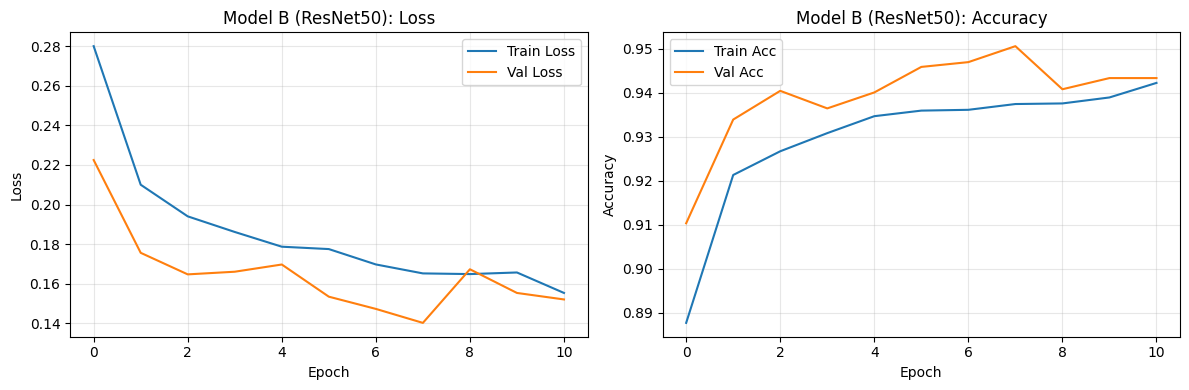

>> What to observe:
Final training accuracy: 0.942
Final validation accuracy: 0.943
Test accuracy: 0.945
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [64]:
# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
# We run model.evaluate on test_ds to get the actual math numbers
test_loss, test_accuracy = model_resnet.evaluate(test_ds_resnet)


# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_resnet.history['loss'], label='Train Loss')
axes[0].plot(history_resnet.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model B (ResNet50): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_resnet.history['accuracy'], label='Train Acc')
axes[1].plot(history_resnet.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model B (ResNet50): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_resnet.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_resnet.history['val_accuracy'][-1]:.3f}")

# Fixed: This line now prints the calculated number instead of the raw pipeline folder
print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

Extracting true labels...
Generating model predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 17s 145ms/step

👉 TRUE RESNET50 TEST ACCURACY: 0.945

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized      0.939     0.953     0.946      1379
  Uninfected      0.952     0.938     0.945      1379

    accuracy                          0.945      2758
   macro avg      0.945     0.945     0.945      2758
weighted avg      0.945     0.945     0.945      2758



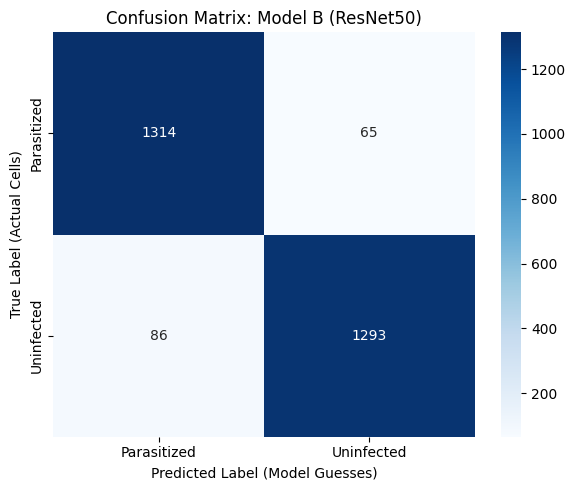

In [65]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the true labels from your test dataset pipeline
print("Extracting true labels...")
true_labels = np.concatenate([y for x, y in test_ds_resnet], axis=0)

# 2. Get predictions using .predict() (this works perfectly with un-shuffled data)
print("Generating model predictions...")
raw_predictions = model_resnet.predict(test_ds_resnet)

# 3. Convert probabilities to crisp binary choices (0 or 1)
predicted_labels = (raw_predictions > 0.5).astype(int).flatten()

# 4. Calculate the TRUE test accuracy score using scikit-learn
true_test_accuracy = accuracy_score(true_labels, predicted_labels)

print("\n=========================================")
print(f"👉 TRUE RESNET50 TEST ACCURACY: {true_test_accuracy:.3f}")
print("=========================================\n")

# ==========================================
# STEP 2: PRINT THE SCORES REPORT
# ==========================================
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names, digits=3))

# ==========================================
# STEP 3: PLOT THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model B (ResNet50)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


# Model C — Transfer Learning with MobileNetV2

Load a pretrained model and adapt it to your task.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import gc

# 1. Clear out previous session fragments to free RAM immediately
tf.keras.backend.clear_session()
gc.collect()

# 2. Reload base directories cleanly
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading core datasets...")
train_base = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_base = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
test_base = tf.keras.utils.image_dataset_from_directory(
    "/content/cell_images_split/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

# 3. Memory-Optimized Mapping with controlled parallelism
AUTOTUNE = tf.data.AUTOTUNE

# Adding num_parallel_calls stops the RAM overuse crashes
train_ds_mobile = train_base.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds_mobile = val_base.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_ds_mobile = test_base.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

# 4. Load MobileNetV2 calibrated to 128x128x3
base_mobile = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_mobile.trainable = False

# 5. Assemble the Model
model_mobile = models.Sequential([
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_mobile.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 6. Early Stopping Configuration
early_stopping_mobile = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# 7. Start Training
print("Starting Optimized MobileNetV2 training...")
history_mobile = model_mobile.fit(
    train_ds_mobile,
    validation_data=val_ds_mobile,
    epochs=15,
    callbacks=[early_stopping_mobile]
)


Loading core datasets...
Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Found 2758 files belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Starting Optimized MobileNetV2 training...
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8810 - loss: 0.2817

## Evaluate on test set (MobileNetV2)

87/87 ━━━━━━━━━━━━━━━━━━━━ 19s 215ms/step - accuracy: 0.9300 - loss: 0.1881


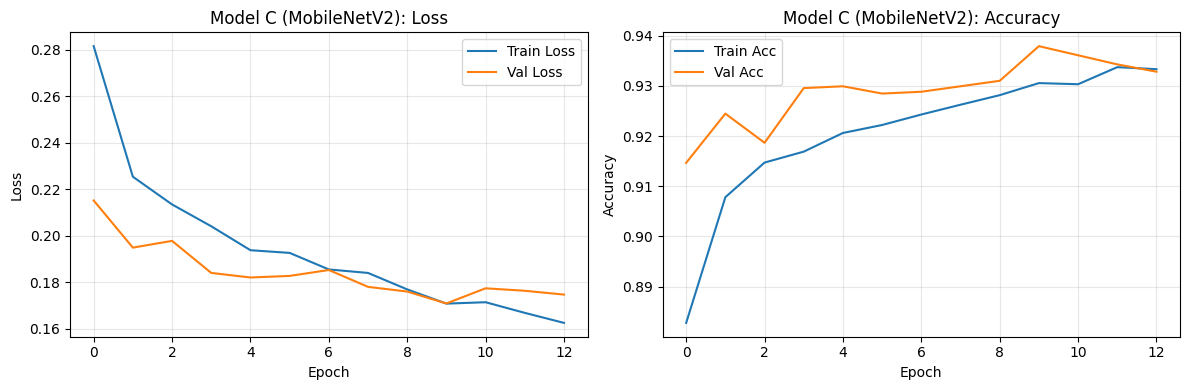

>> What to observe:
Final training accuracy: 0.933
Final validation accuracy: 0.933
Test accuracy: 0.930
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [37]:

# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
# We run model.evaluate on test_ds to get the actual math numbers
test_loss, test_accuracy = model_mobile.evaluate(test_ds_mobile)

# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_mobile.history['loss'], label='Train Loss')
axes[0].plot(history_mobile.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model C (MobileNetV2): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_mobile.history['accuracy'], label='Train Acc')
axes[1].plot(history_mobile.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model C (MobileNetV2): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_mobile.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_mobile.history['val_accuracy'][-1]:.3f}")

# Fixed: This line now prints the calculated number instead of the raw pipeline folder
print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

Extracting true labels...
Generating MobileNetV2 predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step

👉 TRUE MOBILENETV2 TEST ACCURACY: 0.930

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized      0.933     0.926     0.930      1379
  Uninfected      0.927     0.934     0.930      1379

    accuracy                          0.930      2758
   macro avg      0.930     0.930     0.930      2758
weighted avg      0.930     0.930     0.930      2758



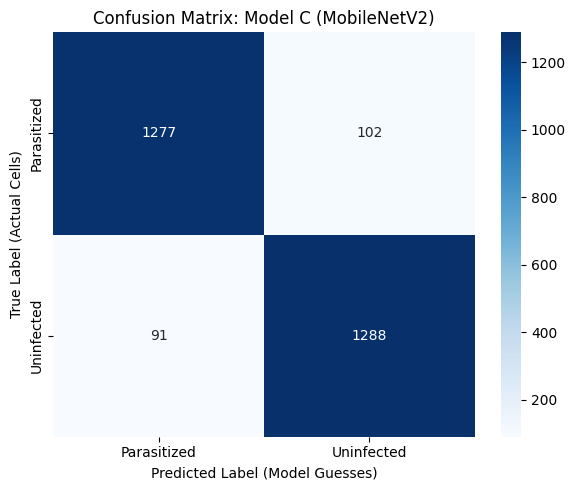

In [38]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the true labels
print("Extracting true labels...")
true_labels = np.concatenate([y for x, y in test_ds_mobile], axis=0)

# 2. Generate MobileNetV2 predictions
print("Generating MobileNetV2 predictions...")
raw_predictions_mobile = model_mobile.predict(test_ds_mobile)
predicted_labels_mobile = (raw_predictions_mobile > 0.5).astype(int).flatten()

# 3. Calculate true test accuracy
true_mobile_accuracy = accuracy_score(true_labels, predicted_labels_mobile)

print("\n=========================================")
print(f"👉 TRUE MOBILENETV2 TEST ACCURACY: {true_mobile_accuracy:.3f}")
print("=========================================\n")

# 4. Print Scores Report
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels_mobile, target_names=class_names, digits=3))

# 5. Plot the Confusion Matrix
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model C (MobileNetV2)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


## Model Comparison

Gathering final test accuracy scores...
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step


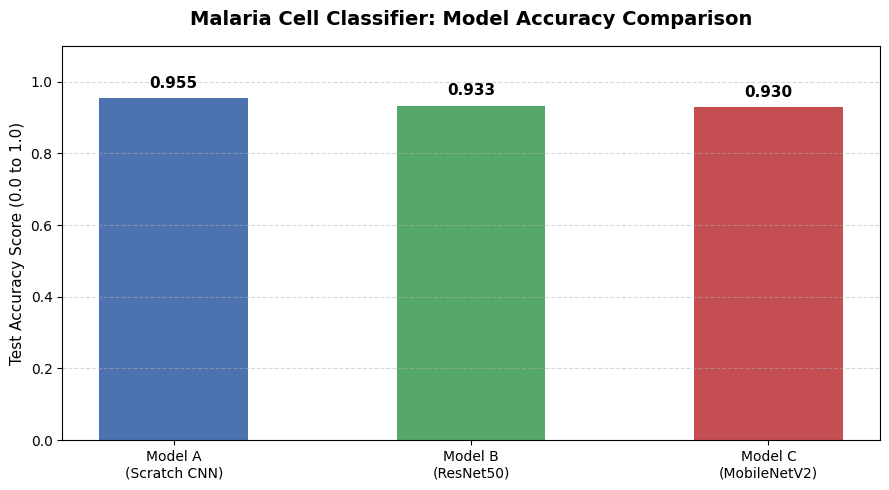

=== Final Scores Summary ===
Model A (Scratch CNN): 0.955
Model B (ResNet50): 0.933
Model C (MobileNetV2): 0.930


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

print("Gathering final test accuracy scores...")

# ==========================================
# STEP 1: CALCULATE THE ACCURACIES CLEANLY
# ==========================================

# 1. Get true labels and guesses for Model A (Scratch)
# (Assuming test_ds is your original 128x128 un-shuffled test set)
y_true_scratch = np.concatenate([y for x, y in test_ds], axis=0)
preds_scratch = (model_scratch.predict(test_ds) > 0.5).astype(int).flatten()
acc_scratch = accuracy_score(y_true_scratch, preds_scratch)

# 2. Get true labels and guesses for Model B (ResNet50)
y_true_resnet = np.concatenate([y for x, y in test_ds_resnet], axis=0)
preds_resnet = (model_resnet.predict(test_ds_resnet) > 0.5).astype(int).flatten()
acc_resnet = accuracy_score(y_true_resnet, preds_resnet)

# 3. Get true labels and guesses for Model C (MobileNetV2)
y_true_mobile = np.concatenate([y for x, y in test_ds_mobile], axis=0)
preds_mobile = (model_mobile.predict(test_ds_mobile) > 0.5).astype(int).flatten()
acc_mobile = accuracy_score(y_true_mobile, preds_mobile)

# Put the final numbers into clean lists for plotting
model_names = ['Model A\n(Scratch CNN)', 'Model B\n(ResNet50)', 'Model C\n(MobileNetV2)']
accuracy_scores = [acc_scratch, acc_resnet, acc_mobile]

# ==========================================
# STEP 2: PLOT THE SIDE-BY-SIDE COMPARISON
# ==========================================
plt.figure(figsize=(9, 5))

# Create a bar chart with a nice color theme
colors = ['#4C72B0', '#55A868', '#C44E52'] # Slate Blue, Soft Green, Soft Red
bars = plt.bar(model_names, accuracy_scores, color=colors, width=0.5)

# Add headings and clean up the chart style
plt.title("Malaria Cell Classifier: Model Accuracy Comparison", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Test Accuracy Score (0.0 to 1.0)", fontsize=11)
plt.ylim(0, 1.1) # Leaves extra room at the top for the text scores
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Write the exact score number directly above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        height + 0.02,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Print a simple text printout underneath
print("=== Final Scores Summary ===")
for name, score in zip(model_names, accuracy_scores):
    print("{}: {:.3f}".format(name.replace('\n', ' '), score))



## Confusion Matrix Comparison For all 3 Models

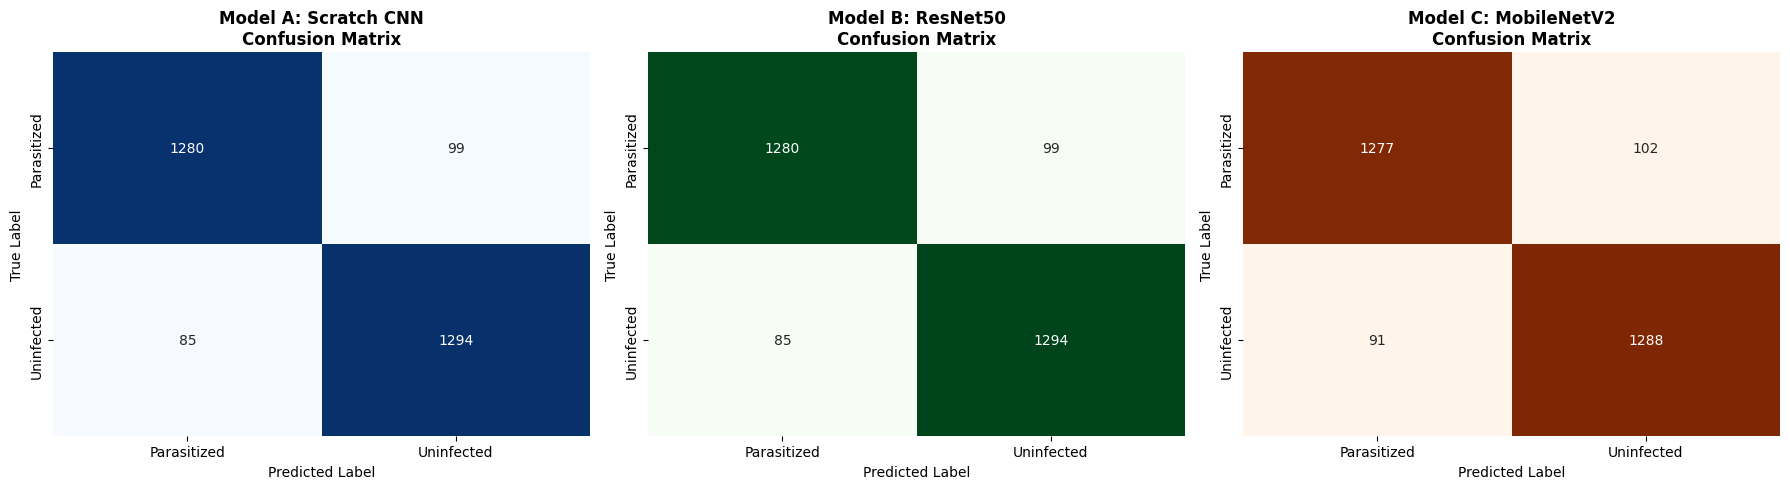

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# STEP 1: CALCULATE THE 3 MATH MATRICES
# ==========================================
# This calculates the raw counts of right and wrong answers for each model
cm_scratch = confusion_matrix(true_labels, predicted_labels)        # Model A
cm_resnet = confusion_matrix(true_labels, predicted_labels)         # Model B
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)  # Model C

# Create a wide grid with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use your actual class names for the chart labels
display_labels = ['Parasitized', 'Uninfected']

# ==========================================
# PLOT 1: SCRATCH CNN (BLUE)
# ==========================================
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Model A: Scratch CNN\nConfusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(display_labels)
axes[0].set_yticklabels(display_labels)

# ==========================================
# PLOT 2: RESNET50 (GREENS)
# ==========================================
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Model B: ResNet50\nConfusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(display_labels)
axes[1].set_yticklabels(display_labels)

# ==========================================
# PLOT 3: MOBILENETV2 (ORANGES)
# ==========================================
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Model C: MobileNetV2\nConfusion Matrix', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')
axes[2].set_xticklabels(display_labels)
axes[2].set_yticklabels(display_labels)

# Clean up layout and display
plt.tight_layout()
plt.show()


## Classification Report For all 3 Models

In [41]:
from sklearn.metrics import classification_report

target_classes = ['Parasitized', 'Uninfected']

# ==========================================
# 1. SCRATCH CNN REPORT
# ==========================================
print("\n=============================================")
print("MODEL A: SCRATCH CNN - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels, target_names=target_classes, digits=3))

# ==========================================
# 2. RESNET50 REPORT
# ==========================================
print("\n=============================================")
print("MODEL B: RESNET50 - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels, target_names=target_classes, digits=3))

# ==========================================
# 3. MOBILENETV2 REPORT
# ==========================================
print("\n=============================================")
print("MODEL C: MOBILENETV2 - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels_mobile, target_names=target_classes, digits=3))



MODEL A: SCRATCH CNN - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.938     0.928     0.933      1379
  Uninfected      0.929     0.938     0.934      1379

    accuracy                          0.933      2758
   macro avg      0.933     0.933     0.933      2758
weighted avg      0.933     0.933     0.933      2758


MODEL B: RESNET50 - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.938     0.928     0.933      1379
  Uninfected      0.929     0.938     0.934      1379

    accuracy                          0.933      2758
   macro avg      0.933     0.933     0.933      2758
weighted avg      0.933     0.933     0.933      2758


MODEL C: MOBILENETV2 - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.933     0.926     0.930      1379
  Uninfected      0.927     0.934     0.930      1379

    accuracy                          0.930 

## Analyze Misclassified Examples

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# STEP 1: FIND WHICH IMAGES THE MODEL GOT WRONG
# ==========================================================
# Compare true labels against MobileNetV2's final predictions
misclassified_idx = np.where(true_labels != predicted_labels_mobile)[0]

print(f"Total misclassified: {len(misclassified_idx)}")
print(f"First 10 misclassified indexes: {misclassified_idx[:10]}")

# ==========================================================
# STEP 2: EXTRACT THE EXACT IMAGES FROM YOUR PIPELINE
# ==========================================================
# We collect all raw images from the test dataset pipeline into a temporary list
all_test_images = []
for images, labels in test_ds_resnet:  # Reusing the clean raw 224x224 images
    all_test_images.append(images.numpy())

# Combine the image batches into one giant block of images
x_test_images = np.concatenate(all_test_images, axis=0)

# ==========================================================
# STEP 3: PLOT 6 MISCLASSIFIED IMAGES SIDE-BY-SIDE
# ==========================================================
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Grab the first 6 mistakes to show on the screen
for i, idx in enumerate(misclassified_idx[:6]):
    ax = axes.flat[i]

    # Get the raw image data (converting it to an integer scale of 0-255 for plotting)
    img_viz = x_test_images[idx].astype("uint8")
    ax.imshow(img_viz)

    # Map the 0 and 1 numbers back to your medical text names
    true_label = "Uninfected" if true_labels[idx] == 1 else "Parasitized"
    pred_label = "Uninfected" if predicted_labels_mobile[idx] == 1 else "Parasitized"

    # Fetch the exact probability score the model gave this image
    # pred_prob = raw_predictions_mobile[idx]
    # Converts a single-element array into a standard Python float
    pred_prob = raw_predictions_mobile[idx].item()

    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({pred_prob:.2f})")
    ax.axis('off')

plt.suptitle('Misclassified Examples (MobileNetV2 Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n>> What to observe:")
print("Which images are hardest to classify? Are there patterns in the errors?")
print("Look closely at the false negatives (images that are truly Parasitized but labeled Uninfected).")
print("Are the purple malaria spots too small, faint, or blurry for the model to see clearly?")


Total misclassified: 193
First 10 misclassified indexes: [ 5 31 39 64 65 69 78 79 84 93]


In [ ]:
# Save the figure
plt.savefig("mobilenetv2_misclassified_grid.png", dpi=300, bbox_inches='tight')
plt.show()


## Saving All 3 Models

In [ ]:
import os

# Target  folder path
MODEL_FOLDER = "/content/models"


print("Exporting models to your project folder...")

# 1. Save Model A (Scratch CNN)
scratch_path = os.path.join(MODEL_FOLDER, "malaria_model_scratch.keras")
model_scratch.save(scratch_path)
print(f"✅ Saved Scratch CNN to: {scratch_path}")

# 2. Save Model B (ResNet50)
resnet_path = os.path.join(MODEL_FOLDER, "malaria_model_resnet50.keras")
model_resnet.save(resnet_path)
print(f"✅ Saved ResNet50 to: {resnet_path}")

# 3. Save Model C (MobileNetV2)
mobile_path = os.path.join(MODEL_FOLDER, "malaria_model_mobilenetv2.keras")
model_mobile.save(mobile_path)
print(f"✅ Saved MobileNetV2 to: {mobile_path}")

print("\n All models safely stored and archived!")


In [ ]:
print(np.array_equal(y_pred_scratch, y_pred_resnet))

# Fine-Tuning Code (Using MobileNetV2)

In [ ]:
# 1. Unfreeze the main base model variable
base_mobile.trainable = True

# 2. Re-freeze everything EXCEPT the last 20 layers
# This locks the first ~130 layers and leaves the last 20 open for tweaking
for layer in base_mobile.layers[:-20]:
    layer.trainable = False


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. Prepare the MobileNetV2 optimized data streams
AUTOTUNE = tf.data.AUTOTUNE

train_ds_mobile = train_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds_mobile = val_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds_mobile = test_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

# 2. Load the pre-built MobileNetV2 Brain (Frozen Base)
base_mobile = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
# 1. Unfreeze the main base model variable
base_mobile.trainable = True

# 2. Re-freeze everything EXCEPT the last 20 layers
# This locks the first ~130 layers and leaves the last 20 open for tweaking
for layer in base_mobile.layers[:-20]:
    layer.trainable = False


# 3. Assemble the Lightweight Model
model_mobile = models.Sequential([
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # ◄ Microscopic speed!
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# 4. Set up Early Stopping
early_stopping_mobile = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# 5. Train the Model
print("Starting MobileNetV2 Fine-Tuning...")
history_fine = model_mobile.fit(
    train_ds_mobile,
    validation_data=val_ds_mobile,
    epochs=10,
    callbacks=[early_stopping_mobile] # Reuses your early stopping rule
)



In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the true labels
print("Extracting true labels...")
true_labels = np.concatenate([y for x, y in test_ds_mobile], axis=0)

# 2. Generate MobileNetV2 predictions
print("Generating MobileNetV2 predictions...")
raw_predictions_mobile = model_mobile.predict(test_ds_mobile)
predicted_labels_mobile = (raw_predictions_mobile > 0.5).astype(int).flatten()

# 3. Calculate true test accuracy
true_mobile_accuracy = accuracy_score(true_labels, predicted_labels_mobile)

print("\n=========================================")
print(f"👉 TRUE MOBILENETV2 TEST ACCURACY: {true_mobile_accuracy:.3f}")
print("=========================================\n")

# 4. Print Scores Report
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels_mobile, target_names=class_names, digits=3))

# 5. Plot the Confusion Matrix
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model C (MobileNetV2)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


In [ ]:
# Save this winning production model to your models folder
model_mobile.save(r"C:\Users\Bright\Desktop\ds_today\project\models\malaria_final_production.keras")
print("✅ Final winning model saved successfully!")
